SECCIONES 9, 10, 11 Y 12

> Este bloque continúa a partir de las secciones 5-8: usa `X_train`, `X_test`, `y_train`, `y_test` (con `SalePrice` en escala logarítmica), el `preprocessor` y el modelo base `dummy_regr` definidos allí.

## 9. Modelo predictivo: Regresión Lineal

Se entrena una **Regresión Lineal** (`LinearRegression`, mínimos cuadrados ordinarios) sobre `SalePrice_log`.

En lugar de entrenar el regresor sobre `X_train_processed`, se arma un `Pipeline` que encadena el `preprocessor` de la sección 7 con el regresor:

- Al llamar `fit` sobre `X_train`, el preprocesador se vuelve a ajustar **solo con los datos de entrenamiento** (mismas medianas, modas y categorías que en la sección 7), así que se mantiene la prevención de fuga de información.
- El objeto resultante recibe los datos **crudos** (con las columnas originales) y devuelve la predicción, por lo que es lo que se guarda en la sección 12: no hay que repetir el preprocesamiento a mano para predecir.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

modelo = Pipeline(steps=[
    ('preprocesador', preprocessor),
    ('regresor', LinearRegression())
])

modelo.fit(X_train, y_train)

n_features = modelo.named_steps['preprocesador'].transform(X_train.head(1)).shape[1]
print(f"Columnas originales: {X_train.shape[1]}")
print(f"Columnas después del preprocesamiento (one-hot + ordinales): {n_features}")
print(f"Intercepto (escala log): {modelo.named_steps['regresor'].intercept_:.4f}")

Columnas originales: 80
Columnas después del preprocesamiento (one-hot + ordinales): 283
Intercepto (escala log): 9.4246


## 10. Evaluación del modelo (MAE, RMSE, R²)

Se evalúan el modelo base (`DummyRegressor`) y la Regresión Lineal con las mismas métricas y sobre los mismos conjuntos:

- **MAE** (error absoluto medio): error promedio, en las unidades de la variable.
- **RMSE** (raíz del error cuadrático medio): penaliza más los errores grandes.
- **R²** (coeficiente de determinación): proporción de la varianza del precio que explica el modelo (1 = perfecto, 0 = igual que predecir la media).

El modelo se entrenó con `SalePrice_log`, así que las métricas se reportan en dos escalas: la **logarítmica** (la que optimiza el modelo) y la de **dólares**, revirtiendo la transformación con `np.expm1` para que el error sea interpretable.

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluar(nombre, y_real_log, y_pred_log):
    y_real = np.expm1(y_real_log)
    y_pred = np.expm1(y_pred_log)
    return {
        'Modelo': nombre,
        'MAE (log)': mean_absolute_error(y_real_log, y_pred_log),
        'RMSE (log)': np.sqrt(mean_squared_error(y_real_log, y_pred_log)),
        'R² (log)': r2_score(y_real_log, y_pred_log),
        'MAE ($)': mean_absolute_error(y_real, y_pred),
        'RMSE ($)': np.sqrt(mean_squared_error(y_real, y_pred)),
        'R² ($)': r2_score(y_real, y_pred),
    }

y_pred_train_lr = modelo.predict(X_train)
y_pred_test_lr = modelo.predict(X_test)

resultados = pd.DataFrame([
    evaluar('Dummy - Train', y_train, y_pred_train_dummy),
    evaluar('Dummy - Test', y_test, y_pred_test_dummy),
    evaluar('Regresión Lineal - Train', y_train, y_pred_train_lr),
    evaluar('Regresión Lineal - Test', y_test, y_pred_test_lr),
]).set_index('Modelo')

resultados.round({
    'MAE (log)': 4, 'RMSE (log)': 4, 'R² (log)': 4,
    'MAE ($)': 0, 'RMSE ($)': 0, 'R² ($)': 4,
})

,MAE (log),RMSE (log),R² (log),MAE ($),RMSE ($),R² ($)
Modelo,,,,,,
Dummy - Train,0.3034,0.3904,0.0000,54603.0,78422.0,-0.0311
Dummy - Test,0.3371,0.4332,-0.0058,59931.0,88271.0,-0.0158
Regresión Lineal - Train,0.0641,0.0929,0.9434,11237.0,17604.0,0.9480
Regresión Lineal - Test,0.0904,0.1299,0.9095,15394.0,23241.0,0.9296


In [7]:
# Mejora relativa de la Regresión Lineal frente al baseline (conjunto de prueba)
dummy_test = resultados.loc['Dummy - Test']
lr_test = resultados.loc['Regresión Lineal - Test']

for metrica in ['MAE ($)', 'RMSE ($)']:
    reduccion = (1 - lr_test[metrica] / dummy_test[metrica]) * 100
    print(f"{metrica}: {dummy_test[metrica]:,.0f} -> {lr_test[metrica]:,.0f}  (reducción del {reduccion:.1f}%)")
print(f"R² (log): {dummy_test['R² (log)']:.4f} -> {lr_test['R² (log)']:.4f}")

MAE ($): 59,931 -> 15,394  (reducción del 74.3%)
RMSE ($): 88,271 -> 23,241  (reducción del 73.7%)
R² (log): -0.0058 -> 0.9095


In [8]:
# Validación cruzada (5 folds) solo sobre el conjunto de entrenamiento,
# para ver qué tan estable es el error según la partición de los datos
from sklearn.model_selection import cross_val_score, KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_cv = -cross_val_score(modelo, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error')

print('RMSE (log) por fold:', np.round(rmse_cv, 4))
print(f'RMSE (log) promedio: {rmse_cv.mean():.4f} ± {rmse_cv.std():.4f}')

RMSE (log) por fold: [0.1451 0.1638 0.2084 0.1436 0.165 ]
RMSE (log) promedio: 0.1652 ± 0.0234


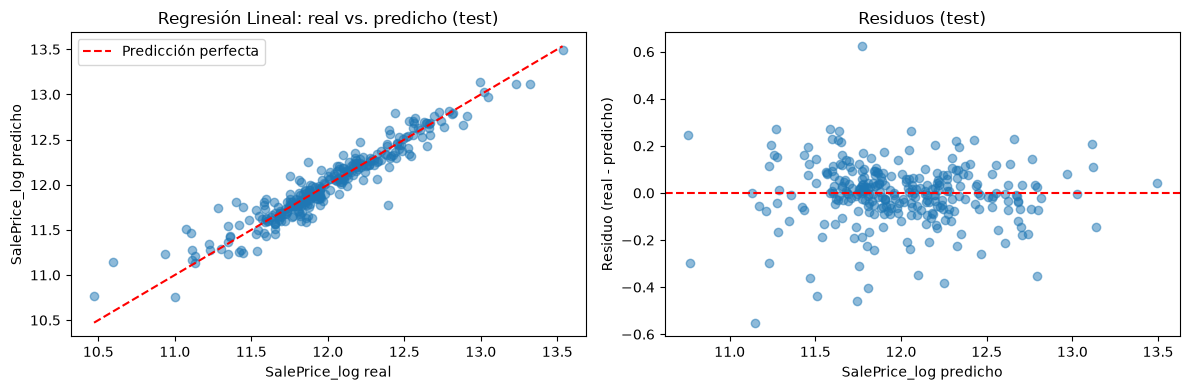

In [9]:
# Real vs. predicho y residuos en el conjunto de prueba
residuos = y_test - y_pred_test_lr

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test, y_pred_test_lr, alpha=0.5)
limites = [y_test.min(), y_test.max()]
axes[0].plot(limites, limites, color='red', linestyle='--', label='Predicción perfecta')
axes[0].set_xlabel('SalePrice_log real')
axes[0].set_ylabel('SalePrice_log predicho')
axes[0].set_title('Regresión Lineal: real vs. predicho (test)')
axes[0].legend()

axes[1].scatter(y_pred_test_lr, residuos, alpha=0.5)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('SalePrice_log predicho')
axes[1].set_ylabel('Residuo (real - predicho)')
axes[1].set_title('Residuos (test)')

plt.tight_layout()
plt.show()

In [10]:
# Viviendas del conjunto de prueba con mayor error
errores = pd.DataFrame({
    'SalePrice real': np.expm1(y_test),
    'SalePrice predicho': np.expm1(y_pred_test_lr).round(0),
    'Error abs. (log)': residuos.abs(),
    'GrLivArea': X_test['GrLivArea'],
    'OverallQual': X_test['OverallQual'],
    'SaleCondition': X_test['SaleCondition'],
}).sort_values('Error abs. (log)', ascending=False)

errores.head(5)

,SalePrice real,SalePrice predicho,Error abs. (log),GrLivArea,OverallQual,SaleCondition
271,241500.0,129452.0,0.623557,1363,7,Normal
30,40000.0,69397.0,0.550947,1317,4,Normal
589,79500.0,125613.0,0.457446,935,5,Normal
1432,64500.0,99835.0,0.436850,968,4,Normal
479,89471.0,134164.0,0.405142,1131,4,Alloca


## 11. Interpretación de resultados

**¿Mejora al baseline?** Sí, de forma clara. El `DummyRegressor` predice siempre el precio promedio, por eso su R² es prácticamente 0 y se equivoca en promedio en unos **\$59.900** por vivienda en el conjunto de prueba. La Regresión Lineal explica cerca del **91% de la varianza** de `SalePrice_log` en prueba (≈93% en dólares) y baja el MAE a unos **\$15.400**: una reducción del **74%** tanto en MAE como en RMSE frente al baseline.

**Dificultades encontradas:**

- **Outliers de `GrLivArea`:** las dos viviendas de más de 4.000 ft² con precio bajo que se señalaron en la sección 3.5 (índices 523 y 1298 del DataFrame, `Id` 524 y 1299) quedaron en el conjunto de entrenamiento. En la validación cruzada, cuando estas casas caen en el fold de validación el modelo les predice un precio muchísimo mayor al real (errores individuales de 1.7 y 2.4 en escala log, frente a errores típicos menores a 0.1), y el fold que contiene la de índice 1298 es el de RMSE más alto (≈0.21). Por eso el RMSE promedio de la validación cruzada (≈0.165) es mayor que el de prueba (≈0.130): el conjunto de prueba no tiene ese tipo de casos. La regresión lineal es muy sensible a estos puntos, y además tiran de los coeficientes al entrenar.
- **Alta dimensionalidad frente al número de filas:** tras el one-hot encoding se pasa de 80 columnas a 283 para solo 1.168 viviendas de entrenamiento. Hay categorías con muy pocas observaciones (p. ej. barrios como `Blueste`, sección 3.3) cuyo coeficiente se estima con poca información. Se nota en la brecha entre entrenamiento y prueba (RMSE log 0.093 vs. 0.130): hay algo de sobreajuste.
- **Multicolinealidad:** varias variables están muy correlacionadas entre sí (sección 3.6) y el one-hot con todas sus categorías genera columnas linealmente dependientes. Las predicciones siguen siendo buenas, pero los coeficientes individuales no son interpretables de forma confiable.
- **Viviendas baratas:** en prueba, los mayores errores son sobre todo casas de bajo precio (\$40.000 – \$90.000) a las que el modelo les asigna un precio mayor; hay pocas viviendas en ese rango para aprender su comportamiento.
- **Error en dólares no uniforme:** como el modelo predice el logaritmo, el error es aproximadamente *proporcional* al precio; en dólares, las casas caras concentran los errores absolutos más grandes (por eso el RMSE en dólares es bastante mayor que el MAE).

**Mejoras futuras:**

1. Aplicar la selección de columnas de la sección 4 (`df_seleccionado`) antes del split, y excluir `Id` de las predictoras, para reducir ruido y multicolinealidad.
2. Usar regresión regularizada (**Ridge** o **Lasso**), que controla el sobreajuste por la cantidad de columnas y, en el caso de Lasso, hace selección de variables automáticamente.
3. Tratar los outliers de `GrLivArea` (eliminar las viviendas con `Id` 524 y 1299 del entrenamiento, o usar una regresión robusta como `HuberRegressor`).
4. Ingeniería de características: superficie total (`TotalBsmtSF + 1stFlrSF + 2ndFlrSF`), edad de la vivienda al venderse (`YrSold - YearBuilt`), agrupar barrios con pocas observaciones, y aplicar log a variables numéricas sesgadas (`LotArea`, `GrLivArea`).
5. Probar modelos no lineales (Random Forest, Gradient Boosting) en las siguientes fases y compararlos contra este modelo como nuevo punto de referencia.

## 12. Guardado del modelo con `joblib`

Se guarda el `Pipeline` completo (preprocesador + Regresión Lineal) en `fase-1/modelo.joblib`. Luego se recarga desde disco y se comprueba que produce **exactamente** las mismas predicciones que el modelo en memoria, y que puede predecir el precio de una vivienda nueva a partir de sus datos crudos.

In [11]:
import joblib

ruta_modelo = 'fase-1/modelo.joblib'
joblib.dump(modelo, ruta_modelo)
print(f'Modelo guardado en: {ruta_modelo}')

Modelo guardado en: fase-1/modelo.joblib


In [12]:
# Recargar el modelo y verificar que predice igual que el original
modelo_cargado = joblib.load(ruta_modelo)

pred_original = modelo.predict(X_test)
pred_cargado = modelo_cargado.predict(X_test)

assert np.allclose(pred_original, pred_cargado), 'El modelo recargado no predice igual que el original'
print('OK: el modelo recargado reproduce las predicciones del original.')
print(f"R² (log) del modelo recargado en test: {r2_score(y_test, pred_cargado):.4f}")

OK: el modelo recargado reproduce las predicciones del original.
R² (log) del modelo recargado en test: 0.9095


In [13]:
# Ejemplo de uso: predecir el precio de viviendas "nuevas" a partir de sus datos crudos
# (se toman 3 filas del conjunto de prueba como ejemplo)
nuevas_viviendas = X_test.head(3)

precio_predicho = np.expm1(modelo_cargado.predict(nuevas_viviendas))  # revertir log1p

pd.DataFrame({
    'SalePrice real': np.expm1(y_test.head(3)).round(0),
    'SalePrice predicho': precio_predicho.round(0),
}, index=nuevas_viviendas.index)

,SalePrice real,SalePrice predicho
892,154500.0,152740.0
1105,325000.0,347834.0
413,115000.0,99384.0
